# In this notebook, we will learn the importent algorithms of machine learning -- linear regression.

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from six.moves import urllib

import tensorflow.compat.v2.feature_column as fc

import tensorflow as tf

from sklearn.model_selection import train_test_split

In [45]:
df_train = pd.read_csv("../../../datasets/泰坦尼克号数据/train.csv")
df_test = pd.read_csv("../../../datasets/泰坦尼克号数据/test.csv")
df_train = df_train.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])
df_test = df_test.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])
# 给训练集数据划分验证集
y_full = df_train.pop("Survived")
y_full

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [46]:
X_full = df_train
X_full

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S
887,1,female,19.0,0,0,30.0000,S
888,3,female,NaN,1,2,23.4500,S
889,1,male,26.0,0,0,30.0000,C


In [47]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42
)
y_val.head()

709    1
439    0
840    0
720    1
39     1
Name: Survived, dtype: int64

In [48]:
y_train.head()

331    0
733    0
382    0
704    0
813    0
Name: Survived, dtype: int64

In [49]:
X_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


In [50]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Sex       712 non-null    object 
 2   Age       572 non-null    float64
 3   SibSp     712 non-null    int64  
 4   Parch     712 non-null    int64  
 5   Fare      712 non-null    float64
 6   Embarked  710 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 44.5+ KB


In [51]:
X_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 179 entries, 709 to 10
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    179 non-null    int64  
 1   Sex       179 non-null    object 
 2   Age       142 non-null    float64
 3   SibSp     179 non-null    int64  
 4   Parch     179 non-null    int64  
 5   Fare      179 non-null    float64
 6   Embarked  179 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 11.2+ KB


In [52]:
X_train.describe()

,Pclass,Age,SibSp,Parch,Fare
count,712.000000,572.000000,712.000000,712.000000,712.000000
mean,2.330056,29.498846,0.553371,0.379213,32.586276
std,0.824584,14.500059,1.176404,0.791669,51.969529
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,2.000000,21.000000,0.000000,0.000000,7.925000
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,38.000000,1.000000,0.000000,30.500000
max,3.000000,80.000000,8.000000,6.000000,512.329200


In [53]:
X_val.describe()

,Pclass,Age,SibSp,Parch,Fare
count,179.000000,142.000000,179.000000,179.000000,179.000000
mean,2.223464,30.505845,0.402235,0.391061,30.684473
std,0.877501,14.656239,0.730703,0.863185,39.447725
min,1.000000,0.830000,0.000000,0.000000,0.000000
25%,1.000000,20.000000,0.000000,0.000000,7.895800
50%,3.000000,29.000000,0.000000,0.000000,14.500000
75%,3.000000,38.750000,1.000000,0.000000,32.410400
max,3.000000,71.000000,4.000000,5.000000,262.375000


In [54]:
y_train.describe()

count    712.000000
mean       0.376404
std        0.484824
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Survived, dtype: float64

In [55]:
y_val.describe()

count    179.000000
mean       0.413408
std        0.493826
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Survived, dtype: float64

In [56]:
df_test.describe()

,Pclass,Age,SibSp,Parch,Fare
count,418.000000,332.000000,418.000000,418.000000,417.000000
mean,2.265550,30.272590,0.447368,0.392344,35.627188
std,0.841838,14.181209,0.896760,0.981429,55.907576
min,1.000000,0.170000,0.000000,0.000000,0.000000
25%,1.000000,21.000000,0.000000,0.000000,7.895800
50%,3.000000,27.000000,0.000000,0.000000,14.454200
75%,3.000000,39.000000,1.000000,0.000000,31.500000
max,3.000000,76.000000,8.000000,9.000000,512.329200


<Axes: >

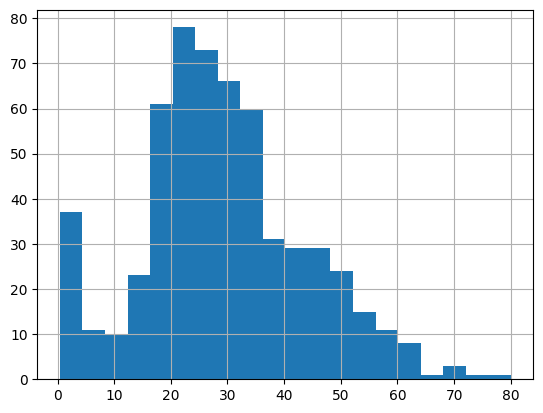

In [57]:
X_train.Age.hist(bins=20)

<Axes: ylabel='Sex'>

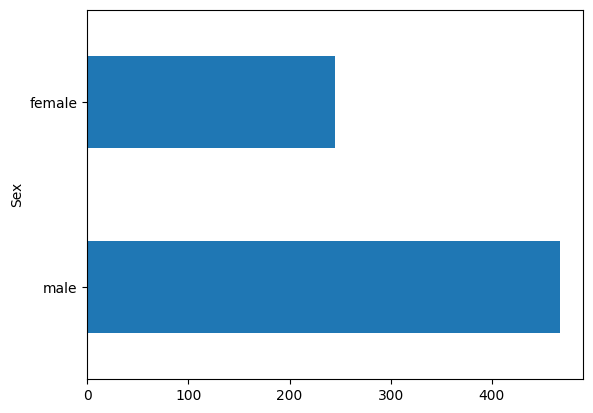

In [58]:
X_train.Sex.value_counts().plot(kind='barh')

<Axes: ylabel='Pclass'>

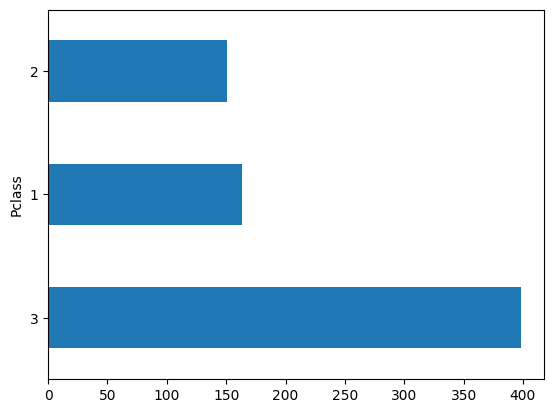

In [59]:
X_train.Pclass.value_counts().plot(kind='barh')

<Axes: ylabel='Sex'>

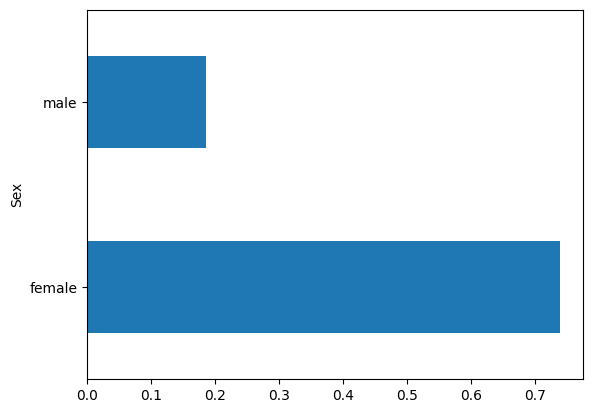

In [60]:
pd.concat([X_train,y_train],axis=1).groupby('Sex').Survived.mean().plot(kind='barh')

In [61]:
# 填补空缺值
X_train['Age'].fillna(X_train['Age'].median(), inplace=True)
X_val['Age'].fillna(X_val['Age'].median(), inplace=True)
df_test['Age'].fillna(df_test['Age'].median(), inplace=True)
X_train['Embarked'].fillna('S', inplace=True)
X_val['Embarked'].fillna('S', inplace=True)
df_test['Embarked'].fillna('S', inplace=True)
X_train['Fare'].fillna(X_train['Fare'].median(), inplace=True)
X_val['Fare'].fillna(X_val['Fare'].median(), inplace=True)
df_test['Fare'].fillna(df_test['Fare'].median(), inplace=True)

C:\Users\hhui8\AppData\Local\Temp\ipykernel_32752\775955913.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['Age'].fillna(X_train['Age'].median(), inplace=True)
C:\Users\hhui8\AppData\Local\Temp\ipykernel_32752\775955913.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [62]:
# 定义分类类别和数值类别
CATEGORIES_COLUMNS = ['Sex', 'Parch', 'SibSp', 'Pclass', 'Embarked']
NUMERIC_COLUMNS = ['Age', 'Fare']

feature_columns = []
for feature_name in CATEGORIES_COLUMNS:
    vocabulary = X_train[feature_name].unique()
    feature_columns.append(tf.feature_column.categorical_column_with_vocabulary_list(feature_name, vocabulary))

for feature_name in NUMERIC_COLUMNS:
    feature_columns.append(tf.feature_column.numeric_column(feature_name, dtype=tf.float32))

In [63]:
def make_input_fn(data_df, label_df, num_epochs=10, shuffle=True, batch_size=32):
    def input_function():
        ds = tf.data.Dataset.from_tensor_slices((dict(data_df), label_df)) # 创建一个tf.data.Dataset对象
        if shuffle:
            ds = ds.shuffle(1000) # 打乱数据集
        ds = ds.batch(batch_size=batch_size).repeat(num_epochs) # 切分数据集为32batchs
        return ds
    return input_function

train_input_fn = make_input_fn(X_train, y_train)
eval_input_fn = make_input_fn(X_val, y_val, num_epochs=1, shuffle=False) # 无需打乱顺序


In [64]:
linear_est = tf.estimator.LinearClassifier(feature_columns=feature_columns)


INFO:tensorflow:Using default config.
INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\hhui8\\AppData\\Local\\Temp\\tmpwq4y49gt', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_checkpoint_save_graph_def': True, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


In [65]:
linear_est.train(train_input_fn)  # 训练模型
result = linear_est.evaluate(eval_input_fn)
clear_output()
print(result['accuracy'])

0.8156425


In [66]:
print(result)

{'accuracy': 0.8156425, 'accuracy_baseline': 0.5865922, 'auc': 0.87310165, 'auc_precision_recall': 0.855788, 'average_loss': 0.4466017, 'label/mean': 0.41340783, 'loss': 0.44825414, 'precision': 0.8360656, 'prediction/mean': 0.35483503, 'recall': 0.6891892, 'global_step': 230}


In [67]:
result = list(linear_est.predict(eval_input_fn))
print(result)

INFO:tensorflow:Calling model_fn.
INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Restoring parameters from C:\Users\hhui8\AppData\Local\Temp\tmpwq4y49gt\model.ckpt-230
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.
[{'logits': array([-1.8094128], dtype=float32), 'logistic': array([0.1407091], dtype=float32), 'probabilities': array([0.8592909, 0.1407091], dtype=float32), 'class_ids': array([0], dtype=int64), 'classes': array([b'0'], dtype=object), 'all_class_ids': array([0, 1]), 'all_classes': array([b'0', b'1'], dtype=object)}, {'logits': array([-1.5991576], dtype=float32), 'logistic': array([0.16809939], dtype=float32), 'probabilities': array([0.8319006 , 0.16809939], dtype=float32), 'class_ids': array([0], dtype=int64), 'classes': array([b'0'], dtype=object), 'all_class_ids': array([0, 1]), 'all_classes': array([b'0', b'1'], dtype=object)}, {'logits': array([-2.402577], dtype=float32), 'logistic': array(